# XFEL Intensity Test Cases — Au at 9.7 keV

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from xfel_calc import (quick, fluence_map, PulseParams,
                       set_plot_style, savefig, threshold_cmap, PETROFF10,
                       FIG_SINGLE, FIG_DOUBLE, FIG_WIDE,
                       FS_TITLE, FS_LABEL, FS_TICK, FS_LEGEND, FS_ANNOT)
import xfel_calc

set_plot_style()

# Set to True to write PNGs
xfel_calc.SAVE = True

## Parameters

In [15]:
# ─── Edit these ───────────────────────────────────────────────────────
E_keV    = 9.7       # photon energy [keV]
fwhm_nm  = 100       # focal spot FWHM [nm] (circular)
element  = 'Au'

cases = [
    # (pulse energy [µJ], pulse duration [fs], label)
    (200,  10, '200 µJ / 10 fs'),
    (1000, 10, '1 mJ / 10 fs'),
    (30,   0.3, '30 µJ / 0.3 fs'),
]
# ──────────────────────────────────────────────────────────────────────

## 1. Run test cases

In [16]:
results = {}
for E_uJ, tau_fs, label in cases:
    r = quick(E_uJ, E_keV=E_keV, fwhm_nm=fwhm_nm, tau_fs=tau_fs, element=element)
    results[label] = r
    print(r)
    print()

═══ XFEL Intensity: Au at 9.70 keV ═══
  E_pulse = 200.0 µJ,  E_photon = 9.70 keV,  FWHM = 100×100 nm²,  τ = 10.0 fs

  N_photons        = 1.287e+11
  A_eff            = 1.133e-10 cm²
  P_peak           = 1.879e+10 W  (18.79 GW)
  I_peak           = 1.658e+20 W/cm²
  Φ₀ (fluence)     = 1.136e+21 ph/cm²
  Φ̇₀ (peak flux)   = 1.067e+35 ph/cm²/s

  σ_photo          = 4.011e-20 cm²/atom  (40113 barn)
  σ_total          = 4.176e-20 cm²/atom

  η (photo)        = 45.559 ph/atom/pulse
  η (total)        = 47.425 ph/atom/pulse
  η′ (M4, τ=302 as)  = 1.2912

  Shell-resolved (with hole lifetimes):
  shell    σ (barn)         η    Γ (eV)   τ_hole (as)          η′    τ_hole/τ
     M1        4382    4.9769      15.0          43.9    0.187804    4.39e-03
     M2        5635    6.3995       9.5          69.3    0.296525    6.93e-03
     M3        9699   11.0152       8.5          77.4    0.331407    7.74e-03
     M4        5152    5.8512       2.2         301.9    1.291165    3.02e-02
     M5       

## 2. η and η′ vs pulse energy

Saved: images/eta_vs_energy.png


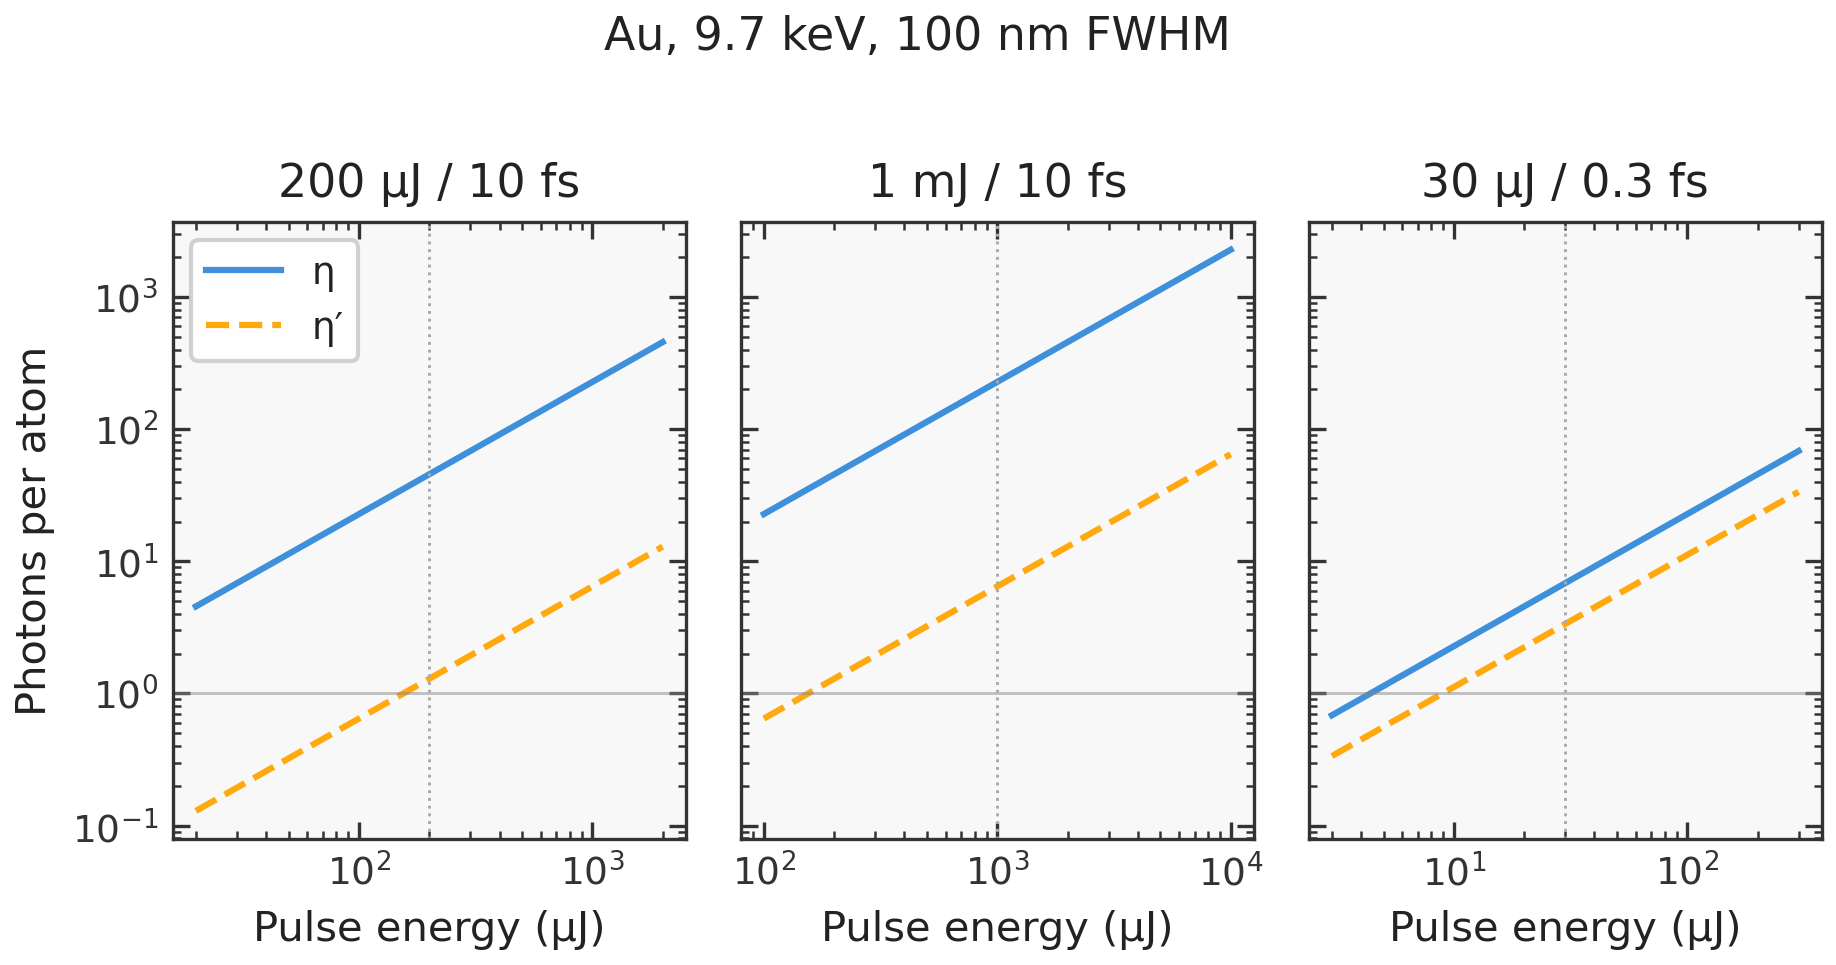

In [17]:
fig, axes = plt.subplots(1, len(cases), figsize=(6.3, 3.2), sharey=True)

for ax, (E_uJ, tau_fs, label) in zip(axes, cases):
    # Scan pulse energy around the case value (0.1× to 10×)
    E_scan = np.logspace(np.log10(E_uJ * 0.1), np.log10(E_uJ * 10), 50)
    eta_vals = [quick(e, E_keV=E_keV, fwhm_nm=fwhm_nm, tau_fs=tau_fs,
                      element=element).eta_photo for e in E_scan]
    ep_vals  = [quick(e, E_keV=E_keV, fwhm_nm=fwhm_nm, tau_fs=tau_fs,
                      element=element).eta_prime_val for e in E_scan]

    ax.loglog(E_scan, eta_vals, color=PETROFF10[0], label='η')
    ax.loglog(E_scan, ep_vals, color=PETROFF10[1], ls='--', label="η′")
    ax.axhline(1, color='#888888', ls='-', lw=0.7, alpha=0.5)
    ax.axvline(E_uJ, color='#aaaaaa', ls=':', lw=0.7)
    ax.set_xlabel('Pulse energy (µJ)')
    ax.set_title(label)

axes[0].set_ylabel('Photons per atom')
axes[0].legend(fontsize=FS_LEGEND)
fig.suptitle(f'{element}, {E_keV} keV, {fwhm_nm} nm FWHM', fontsize=FS_TITLE, y=1.02)
fig.tight_layout()
savefig(fig, 'eta_vs_energy')
plt.show()

## 3. Focal-plane maps: η (top) and η′ (bottom)

Desaturated viridis below η = 1 (linear regime); full colour above
(nonlinear). Same spatial profile in both rows — colour onset shifts
because η′ ≪ η. η′ uses the dominant M-hole lifetime.

Saved: images/focal_plane_maps.png


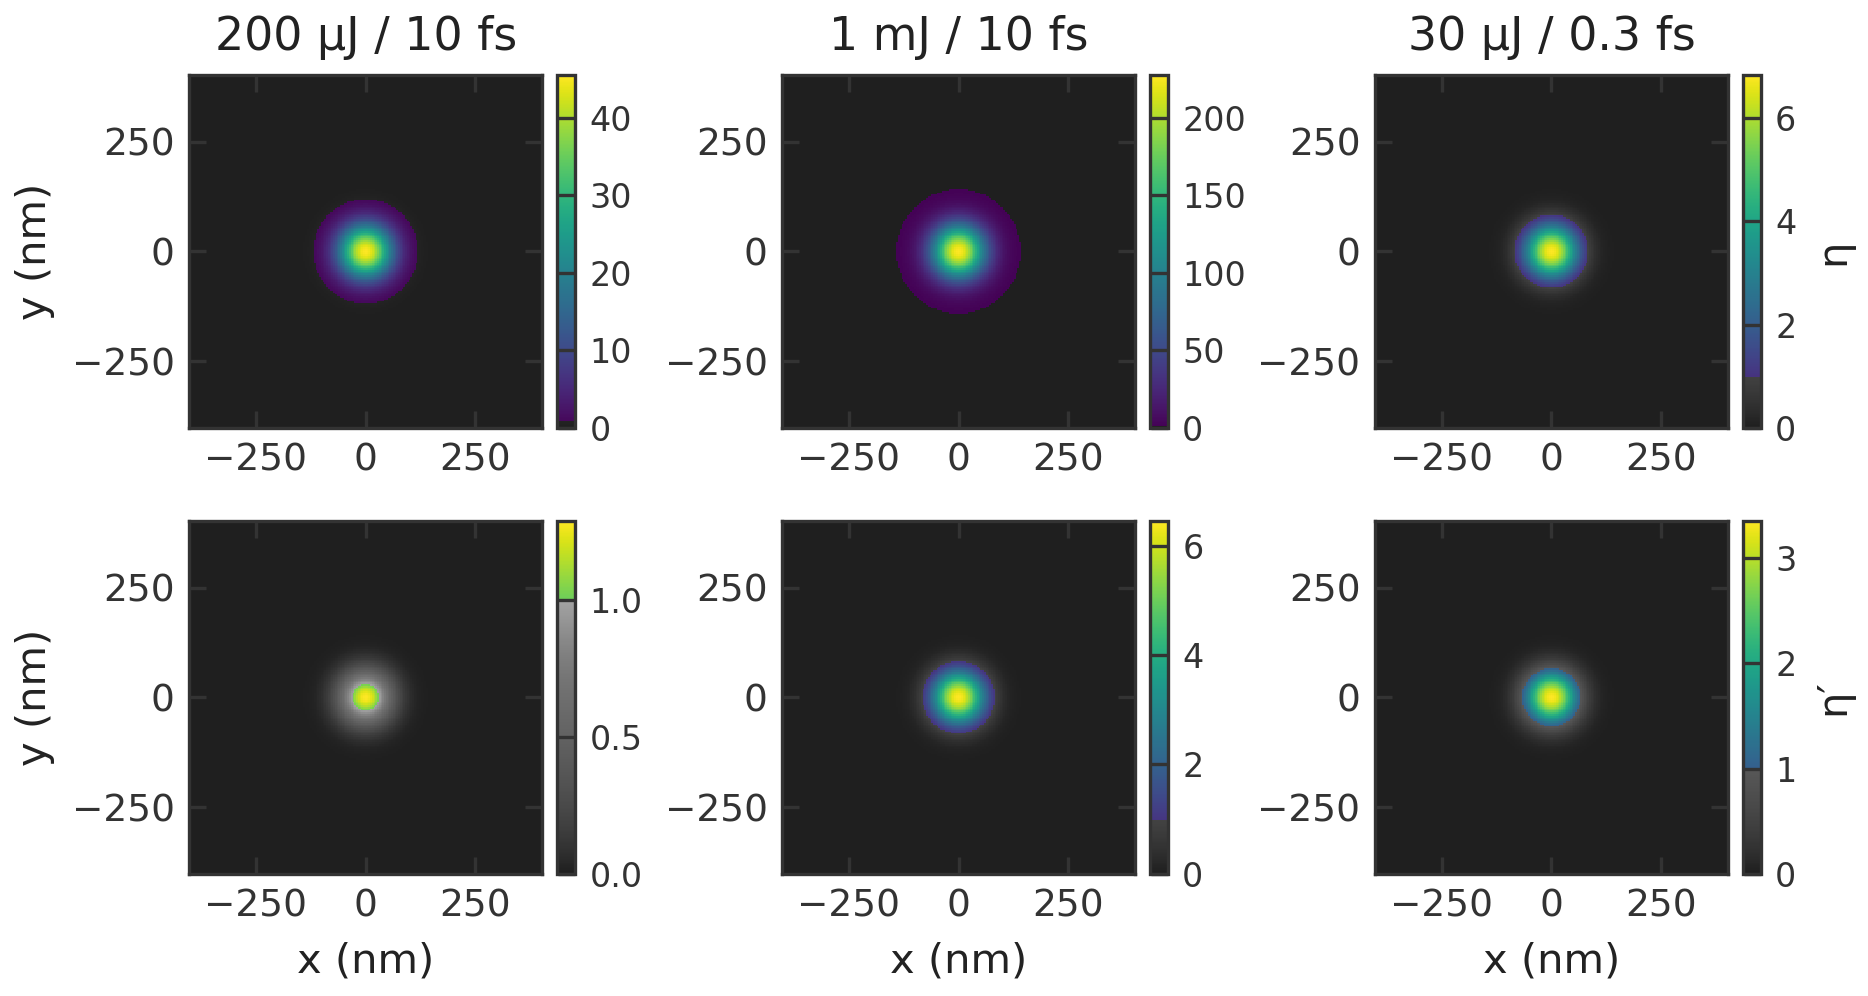

In [18]:
maps_eta, maps_etap = [], []
for E_uJ, tau_fs, label in cases:
    p = PulseParams(E_pulse=E_uJ*1e-6, E_photon_keV=E_keV,
                    fwhm_x=fwhm_nm*1e-9, fwhm_y=fwhm_nm*1e-9, tau=tau_fs*1e-15)
    x, y, fl, eta_2d, etap_2d = fluence_map(p, element=element, extent_nm=400, n_pts=201)
    maps_eta.append(eta_2d)
    maps_etap.append(etap_2d)

fig, axes = plt.subplots(2, len(cases), figsize=(6.3, 3.5))

for col, (E_uJ, tau_fs, label) in enumerate(cases):
    # η row
    cmap_e, norm_e = threshold_cmap(0, maps_eta[col].max(), threshold=1.0)
    ax = axes[0, col]
    im0 = ax.pcolormesh(x, y, maps_eta[col], cmap=cmap_e, norm=norm_e, shading='auto')
    ax.set_aspect('equal')
    ax.set_title(label)
    if col == 0:
        ax.set_ylabel('y (nm)')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cb = fig.colorbar(im0, cax=cax)
    cb.ax.tick_params(labelsize=FS_ANNOT)
    if col == len(cases) - 1:
        cb.set_label('η', fontsize=FS_LABEL)

    # η' row
    cmap_p, norm_p = threshold_cmap(0, max(maps_etap[col].max(), 0.01),
                                     threshold=1.0)
    ax = axes[1, col]
    im1 = ax.pcolormesh(x, y, maps_etap[col], cmap=cmap_p, norm=norm_p, shading='auto')
    ax.set_aspect('equal')
    ax.set_xlabel('x (nm)')
    if col == 0:
        ax.set_ylabel('y (nm)')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cb = fig.colorbar(im1, cax=cax)
    cb.ax.tick_params(labelsize=FS_ANNOT)
    if col == len(cases) - 1:
        cb.set_label("η′", fontsize=FS_LABEL)

fig.tight_layout()
savefig(fig, 'focal_plane_maps')
plt.show()

## 5. Cross-section vs photon energy

Saved: images/cross_sections_vs_energy.png


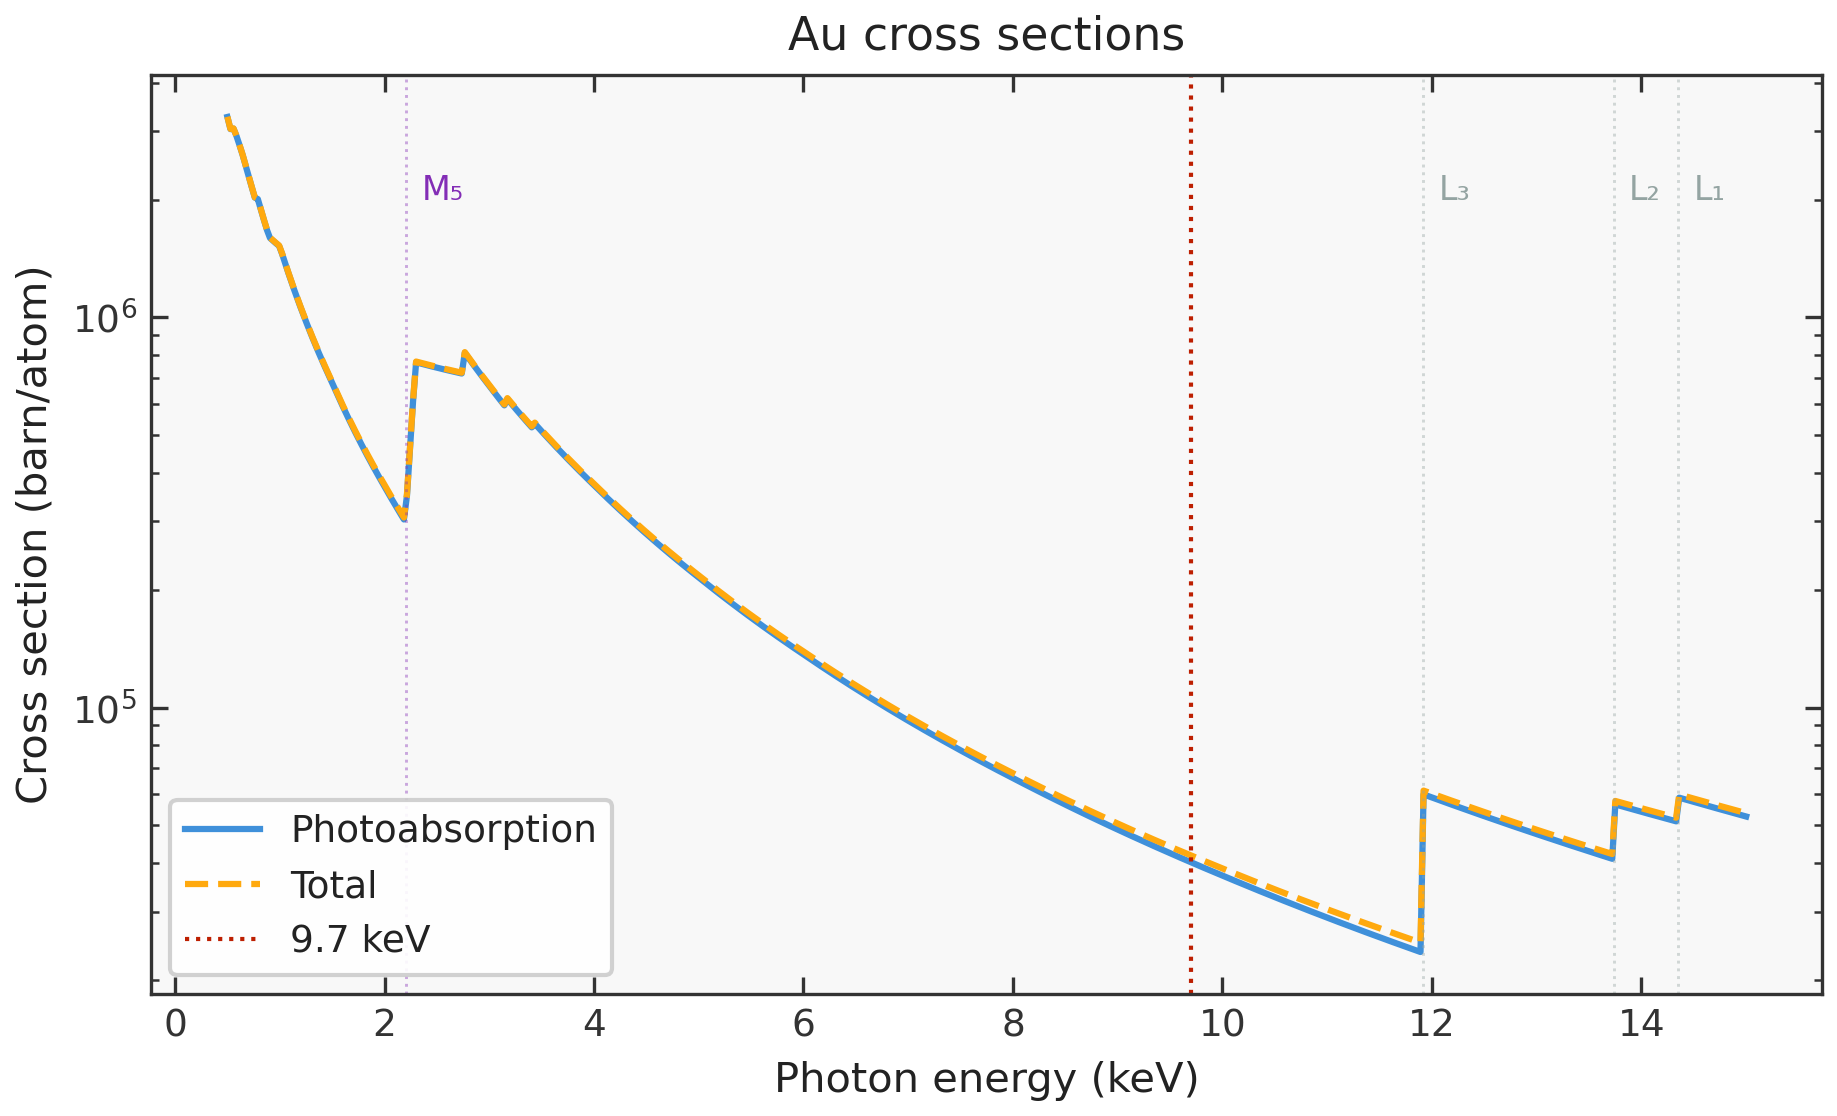

In [19]:
fig, ax = plt.subplots(figsize=FIG_SINGLE)

import xraylib as xrl
from xfel_calc import N_A

E_range = np.linspace(0.5, 15, 500)
Z = xrl.SymbolToAtomicNumber(element)
A_r = xrl.AtomicWeight(Z)
to_atom = A_r / N_A

sig_photo = np.array([xrl.CS_Photo(Z, e) * to_atom for e in E_range])
sig_total = np.array([xrl.CS_Total(Z, e) * to_atom for e in E_range])

ax.semilogy(E_range, sig_photo * 1e24, color=PETROFF10[0], label='Photoabsorption')
ax.semilogy(E_range, sig_total * 1e24, color=PETROFF10[1], ls='--', label='Total')
ax.axvline(E_keV, color=PETROFF10[2], ls=':', lw=1, label=f'{E_keV} keV')

for shell, name, c in [('L3_SHELL','L₃',PETROFF10[3]), ('L2_SHELL','L₂',PETROFF10[3]),
                         ('L1_SHELL','L₁',PETROFF10[3]),
                         ('M5_SHELL','M₅',PETROFF10[4])]:
    edge = xrl.EdgeEnergy(Z, getattr(xrl, shell))
    ax.axvline(edge, color=c, ls=':', alpha=0.4, lw=0.7)
    ax.text(edge + 0.15, 2e6, name, fontsize=FS_ANNOT, color=c)

ax.set_xlabel('Photon energy (keV)')
ax.set_ylabel('Cross section (barn/atom)')
ax.set_title(f'{element} cross sections')
ax.legend()
fig.tight_layout()
savefig(fig, 'cross_sections_vs_energy')
plt.show()